# Occurrence rate

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from scipy.stats import gaussian_kde

In [3]:
from exogaia.data import GaiaAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.planets import OccurrenceRate

In [4]:
occ_rate = OccurrenceRate(primary_mass=np.full(500, 1.0), occ_rate="cls_fulton2021")
sma, mass_planet = occ_rate.sample_planets(allow_reject=False, seed=1)


Occurrence rate

Occurrence rate: cls_fulton2021

Valid ranges:
   - Semi-major axis (au): 0.03 - 30.00
   - Companion mass (Mjup): 0.09 - 18.88

Primary mass range (Msun): 1.00 - 1.00

--------------
Sample planets
--------------

Number of stars: 500
Number of planets: 500

Semi-major axis range (au) = 0.04 - 29.32
Companion mass range (Msun) = 9.08e-05 - 1.78e-02


In [5]:
xy = np.vstack([np.log10(sma), np.log10(mass_planet)])
kde = gaussian_kde(xy)

x_points = np.geomspace(0.04, 100, 200)
y_points = np.geomspace(4e-5, 3e-2, 200)
x_grid, y_grid = np.meshgrid(x_points, y_points)

positions = np.vstack([x_grid.ravel(), y_grid.ravel()])
z_grid = kde(np.log10(positions)).reshape(x_grid.shape)

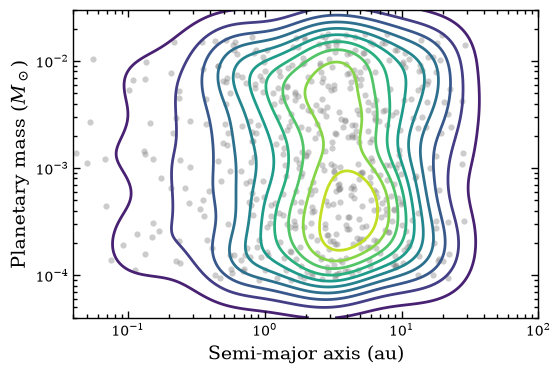

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(sma, mass_planet, s=20, alpha=0.4, lw=0.0, color="gray")
plt.contour(x_grid, y_grid, z_grid, levels=10, linewidths=2.0)
plt.xlabel("Semi-major axis (au)", fontsize=14)
plt.ylabel(r"Planetary mass ($M_\odot$)", fontsize=14)
plt.loglog()
plt.show()

In [7]:
source_id = 2603090003484152064  # Gliese 876
primary_mass = (0.35, 0.01)  # (Msun)

In [8]:
epoch_astrom = GaiaAstrometry(primary_mass=primary_mass, gaia_release='DR5')


Gaia astrometry

Gaia release: DR5
Reference epoch: J2020.000

Primary mass (Msun): 0.35 +/- 0.01


In [9]:
star_param = epoch_astrom.query_source(source_id=source_id, gaia_release='DR3')


---------------
Querying source
---------------

Gaia release: DR3
Source ID: 2603090003484152064

INFO: Query finished. [astroquery.utils.tap.core]

RA = 343.324 deg +/- 0.034 mas
Dec = -14.267 deg +/- 0.026 mas
Parallax = 214.038 +/- 0.036 mas
Proper motion in RA = 957.715 +/- 0.041 mas/yr
Proper motion in Dec = -673.601 +/- 0.031 mas/yr
G-band magnitude = 8.875
Pseudocolor = 1.26 um-1

UWE = 2.82
RUWE = 1.34
Astrometric excess noise (mas) = 0.2433 +/- 0.0043
Non single star = 1


In [10]:
model_param = epoch_astrom.simulate_data(
    model_param=None,
    mass_2=None,
    flux_ratio=None,
    occ_rate="cls_fulton2021",
    sigma_per_ccd=None,
    csv_out=None,
    seed=1,
    allow_reject=False,
)


Occurrence rate

Occurrence rate: cls_fulton2021

Valid ranges:
   - Semi-major axis (au): 0.03 - 30.00
   - Companion mass (Mjup): 0.09 - 18.88

Primary mass (Msun): 0.35

--------------
Sample planets
--------------

Number of stars: 1
Number of planets: 1

Semi-major axis (au) = 0.07
Companion mass (Msun) = 4.15e-03

-------------
Simulate data
-------------

System type: binary

Primary mass (Msun): 0.35 +/- 0.01

AL scan uncertainty (per CCD) = 125.70 uas
AL scan uncertainty (per transit) = 44.44 uas

Additional parameters:
   - Primary mass (Msun) = 0.35
   - Companion mass (Msun) = 4.15e-03
   - Mass ratio = 1.19e-02
   - Flux ratio = 1.82e-07
   - Relative semi-major axis (au) = 0.07

Star model

Epoch astrometry: GaiaAstrometry

-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = 0.000
   - Dec offset (mas) = 0.000
   - Parallax (mas) = 214.038
   - Proper motion in RA (mas/yr) = 957.715
   - Proper motion in Dec

In [11]:
print(model_param)

{'parallax': 214.0379888743159, 'pm_ra': 957.7147312894218, 'pm_dec': -673.6012364809744, 'ra_offset': 0.0, 'dec_offset': 0.0, 'sma': np.float64(0.16844883447443273), 'ecc': 0.35401127382333, 'inc': np.float64(1.7247508804344085), 'aop': 2.0590161226172405, 'pan': 2.57107400134529, 'tau': 0.5495936876730595, 'per': 10.679728515744854}
